# Financial Fraud Detection

- The objective of this notebook is to showcase the usage of the [___financial-fraud-training___ container](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/cugraph/containers/financial-fraud-training) and how to deploy the produced trained models on [NVIDIA Dynamo-Triton](https://catalog.ngc.nvidia.com/orgs/nvidia/containers/tritonserver).
- We use [IBM TabFormer](https://github.com/IBM/TabFormer) as an example dataset and the dataset is preprocess before model training

NOTE:
* The preprocessing code is written specifically for the TabFormer dataset and will not work with other datasets.
* Additionally, a familiarity with [Jupyter](https://docs.jupyter.org/en/latest/what_is_jupyter.html) is assumed.

# Environment Setup (Local and Brev)
This Notebook is designed to work in both a ___Local___ and ___Brev___ environment.  However, there are a few slight differences that will be pointed out. 

### For Local Environment Setup
Please create a Conda environment and add that to the notebook - See the [README](../README.md) file

In [1]:
# default host for local run
HOST = "0.0.0.0"
BREV = False

### For Brev Environment Setup

In [ ]:
!pip install -r "./requirements.txt"

In [ ]:
BREV = True

In [ ]:
# Brev public IP address
if BREV:
    HOST = 'host.docker.internal'
HOST

-----
## Import libraries (both environments)

In [2]:
import os
import sys
import json
import time

!pip install networkx
!pip install torch --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.0 MB/s  0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 77.2 MB/s  0:00:07:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 97.1 MB/s  0:00:00m0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 91.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 79.8 MB/s  0:00:06:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 90.4 MB/s  0:00:04:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 98.1 MB/s  0:00:01:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 98.7 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 92.9 MB/s  0:00:01:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 98.6 MB/s  0:00:0

----
# Step 1: Get and Prepare the data

## For Local
1. Download the dataset: https://ibm.ent.box.com/v/tabformer-data/folder/130747715605
2. untar and uncompreess the file: `tar -xvzf ./transactions.tgz`
3. Put card_transaction.v1.csv in in the `data/TabFormer/raw` folder


## For Brev 
1. Download the dataset: https://ibm.ent.box.com/v/tabformer-data/folder/130747715605
2. In the Jupyter notebook window, use the "File Browser" section to the data/Tabformer/raw folder
3. Drag-and-drop the "transactions.tgz" file into the folder
    - There is also an "upload" option that displays a file selector
    - Please wait for the upload to finish, it could take a while, by lookign at the status indocator at the bottom of the window
4. Now uncompress and untar by running the following command
    - Note: if somethign goes wrong you will need to delete the file rather than trying to overwrite it.

In [ ]:
# verify that the compressed file was uploaded successfully - the size should be 266M
!ls -lh ../data/TabFormer/raw

In [ ]:
# Uncompress/untar the file
!tar xvzf ../data/TabFormer/raw/transactions.tgz -C ../data/TabFormer/raw/

__If__ drag-and-drop is not working, please run the [Download TabFormer](./extra/download-tabformer.ipynb) notebook is the "extra" folder 

## Check data folder structure
The goal is to produce the following structure

```
.
    data
    └── TabFormer
        └── raw
            └── card_transaction.v1.csv
```

In [3]:
# Once the raw data is placed as described above, set the path to the TabFormer directory

# Change this path to point to TabFormer data
data_root_dir = os.path.abspath('../data/TabFormer/') 

# Change this path to the directory where you want to save your model
model_output_dir = os.path.join(data_root_dir, 'trained_models')

# Path to save the trained model
os.makedirs(model_output_dir, exist_ok=True)

### Define python function to print directory tree

In [4]:
def print_tree(directory, prefix=""):
    """Recursively prints the directory tree starting at 'directory'."""
    # Retrieve a sorted list of entries in the directory
    entries = sorted(os.listdir(directory))
    entries_count = len(entries)
    
    for index, entry in enumerate(entries):
        path = os.path.join(directory, entry)
        # Determine the branch connector
        if index == entries_count - 1:
            connector = "└── "
            extension = "    "
        else:
            connector = "├── "
            extension = "│   "
        
        print(prefix + connector + entry)
        
        # If the entry is a directory, recursively print its contents
        if os.path.isdir(path):
            print_tree(path, prefix + extension)

In [5]:
# Check if the raw data has been placed properly
print_tree(data_root_dir)

├── raw
│   ├── card_transaction.v1.csv
│   └── readme.md
└── trained_models


---
# Step 2: Preprocess the data 
- Import the Python function for preprocessing the TabFormer data
- Call `preprocess_TabFormer` function to prepare the data

NOTE: The preprocessing can takes a few minutes


In [6]:
# Add the "src" directory to the search path
src_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), 'src'))
sys.path.insert(0, src_dir)

# should be able to import from "src" folder now
from preprocess_TabFormer import preprocess_data

In [7]:
# Preprocess the data
mask_mapping, feature_mask = preprocess_data(data_root_dir)

# this will output status as it correlates different attributes with target column

Correlation (Card, Fraud) =   6.59%
Correlation (Chip, Fraud) =   5.63%
Correlation (Errors, Fraud) =   1.81%
Correlation (State, Fraud) =  35.92%
Correlation (City, Fraud) =  32.47%
Correlation (Zip, Fraud) =  14.99%
Correlation (MCC, Fraud) =  12.70%
Correlation (Merchant, Fraud) =  34.88%
Correlation (User, Fraud) =   3.40%
Correlation (Day, Fraud) =   0.26%
Correlation (Month, Fraud) =   0.23%
Correlation (Year, Fraud) =   2.35%
r_pb (Time) = -0.00 with p_value 0.00
r_pb (Amount) = 0.03 with p_value 0.00
Transaction ID range (np.int64(0), np.int64(301523))
Merchant ID range (np.int64(0), np.int64(42941))
User ID range (np.int64(0), np.int64(4872))
Transaction ID range (np.int64(0), np.int64(25802))
Merchant ID range (np.int64(0), np.int64(6772))
User ID range (np.int64(0), np.int64(4794))


In [8]:
# You should not see files under a "gnn" folder and under a "xgb" folder
print_tree(data_root_dir)

├── gnn
│   ├── edges
│   │   └── node_to_node.csv
│   ├── nodes
│   │   ├── node.csv
│   │   ├── node_label.csv
│   │   └── offset_range_of_training_node.json
│   └── test_gnn
│       ├── edges
│       │   └── node_to_node.csv
│       └── nodes
│           ├── node.csv
│           └── node_label.csv
├── raw
│   ├── card_transaction.v1.csv
│   └── readme.md
├── trained_models
└── xgb
    ├── test.csv
    ├── training.csv
    └── validation.csv


-----
# Step 3:  Now train the model using the financial-fraud-training container


## Create training configuration file
NOTE: Training configuration file must conform to schema defined [here](https://docs.nvidia.com/nim/financial-fraud-training/latest/configuration/config-json.html)

__Important: Models and configuration files needed for deployment using NVIDIA Dynamo-Triton will be saved in model-repository under the folder that is mounted in /trained_models inside the container__

In [9]:
training_config = {
  "paths": {
    "data_dir": "/data", # Mount dataset root directory under /data in the container
    "output_dir": "/trained_models" # Mount path to save the trained models.
                                    # NOTE: This path is inside the docker container 
  },

  "models": [
    {
      "kind": "GraphSAGE_XGBoost",
      "gpu": "single",
      "hyperparameters": {
        "gnn":{
          "hidden_channels": 16,
          "n_hops": 1,
          "dropout_prob": 0.1,
          "batch_size": 1024,
          "fan_out": 16,
          "num_epochs": 16
        },
        "xgb": {
          "max_depth": 6,
          "learning_rate": 0.2,
          "num_parallel_tree": 3,
          "num_boost_round": 512,
          "gamma": 0.0
        }

      }
    }
  ]
}


#### Save the training configuration as a json file

In [10]:
training_config_file_name = 'training_config.json'

with open(os.path.join(training_config_file_name), 'w') as json_file:
    json.dump(training_config, json_file, indent=4)

## Pull and run the financial_fraud_training container


#### Logging into the NVIDIA Container Registry.

The NVIDIA NGC API Key is a mandatory key that is required to use this blueprint. This is needed to log into the NVIDIA container registry, nvcr.io, and to pull secure container images used in this NVIDIA NIM Blueprint. Refer to [Generating NGC API Keys](https://docs.nvidia.com/ngc/gpu-cloud/ngc-user-guide/index.html#generating-api-key) in the NVIDIA NGC User Guide for more information.


In [11]:
API_KEY=""

#### Authenticate with the NVIDIA Container Registry with the following command

In [12]:
!echo "$API_KEY" | docker login nvcr.io --username '$oauthtoken' --password-stdin

Login Succeeded


#### Pull the container image from the NGC registry

In [13]:
!docker pull nvcr.io/nvidia/cugraph/financial-fraud-training:1.0.1

1.0.1: Pulling from nvidia/cugraph/financial-fraud-training

b265507a: Pulling fs layer 
8769314d: Pulling fs layer 
b700ef54: Pulling fs layer 
63dd6b7e: Pulling fs layer 
80752b35: Pulling fs layer 
59b21c0f: Pulling fs layer 
04ab24c5: Pulling fs layer 
1553aeb1: Pulling fs layer 
ff093155: Pulling fs layer 
4e451322: Pulling fs layer 
12f82f03: Pulling fs layer 
fd5dddb1: Pulling fs layer 
8ea39070: Pulling fs layer 
3b71b07b: Pulling fs layer 
dd940fc6: Pulling fs layer 
4f040cbe: Pulling fs layer 
16b4865e: Pulling fs layer 
45aa1d7e: Pulling fs layer 
6e8d8318: Pulling fs layer 
024db52a: Pulling fs layer 
6a22ad93: Pulling fs layer 
a953a32b: Pulling fs layer 
77b797d2: Pulling fs layer 
2d5b1cc1: Pulling fs layer 
23c296bb: Pulling fs layer 
583d0756: Pulling fs layer 
8363f368: Pulling fs layer 
3134baa1: Pulling fs layer 
d4d2d207: Pulling fs layer 
09fcf888: Pulling fs layer 
c0c51577: Pulling fs layer 
fc731425: Pulling fs layer 
7e3f78ba: Pulling fs layer 
04527ac4: Pulli

#### Set container name and ports for running the container

In [14]:
NIM_HTTP_PORT = 8002
NIM_GRPC_PORT = 50051
CONTAINER_NAME = "financial-fraud-training"
gnn_data_dir = os.path.join(data_root_dir, "gnn")

In [15]:
# Stop any running container with the same name
container_ids = !docker ps --filter "name={CONTAINER_NAME}" -q
if len(container_ids) > 0:
    !docker stop {CONTAINER_NAME}

#### Run the container

In [16]:
if BREV:
    host_path_gnn_data = gnn_data_dir.replace('/root/verb-workspace', '/home/ubuntu/workspace')
    host_path_trained_models = model_output_dir.replace('/root/verb-workspace', '/home/ubuntu/workspace')
else:
    host_path_gnn_data = gnn_data_dir
    host_path_trained_models = model_output_dir


In [17]:
!docker run -d -it --rm --name={CONTAINER_NAME} --gpus "device=0" \
    -p {NIM_HTTP_PORT}:{NIM_HTTP_PORT} -e NIM_HTTP_API_PORT={NIM_HTTP_PORT} -p {NIM_GRPC_PORT}:{NIM_GRPC_PORT} \
    -e NIM_DISABLE_MODEL_DOWNLOAD=True -e NIM_GRPC_API_PORT={NIM_GRPC_PORT} -v {host_path_gnn_data}:/data \
    -v {host_path_trained_models}:/trained_models nvcr.io/nvidia/cugraph/financial-fraud-training:1.0.1 -e NGC_API_KEY={API_KEY}

98b718c30853150abe14f692c96623fea714a2ca9331a0fc01bac14998f7681a


In [ ]:
time.sleep(5)

#### Finally, initiate model training using the training configuration defined earlier

- Initiate training via the /train endpoint by sending the training configuration as a JSON payload.

In [18]:
!curl -X POST "http://{HOST}:$NIM_HTTP_PORT/train"   -H "Content-Type: application/json"   -d @{training_config_file_name}

{"message":"Successfully completed the training"}

In [19]:
container_ids = !docker ps --filter "name={CONTAINER_NAME}" -q
if len(container_ids) > 0:
    !docker stop {CONTAINER_NAME}

financial-fraud-training


#### Make sure that `python_backend_model_repository` has been created with right contents
According to the training configuration file defined earlier, if the trining run successfully, a folder titled `python_backend_model_repository` containing a python backend model and a configuration file will be created under 
{model_output_dir} and its contents should look like

```sh
python_backend_model_repository/
└── prediction_and_shapley
    ├── 1
    │   ├── embedding_based_xgboost.json
    │   ├── model.py
    │   └── state_dict_gnn_model.pth
    └── config.pbtxt

```


In [20]:
print_tree(os.path.join(model_output_dir, 'model_repository'))

├── model
│   ├── 1
│   │   └── graph_sage_node_embedder.onnx
│   └── config.pbtxt
└── xgboost
    ├── 1
    │   └── xgboost_on_embeddings.json
    └── config.pbtxt


----
# Step 4:  Serve your python backend model using NVIDIA Dynamo-Triton
__!Important__: Change MODEL_REPO_PATH to point to `{model_output_dir}` / `python_backend_model_repository` if you used a different path in your training configuration file

#### Install NVIDIA Dynamo-Triton Client

In [21]:
mamba install -n fraud_blueprint_env -y compilers

[+] 0.0s
[+] 0.0s

Pinned packages:

  - python=3.13


Transaction

  Prefix: /home/innoai/conda/envs/fraud_blueprint_env

  Updating specs:

   - compilers


  Package                     Version  Build                 Channel         Size
───────────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────────

  + binutils                   2.45.1  default_h4852527_102  conda-forge     35kB
  + binutils_impl_linux-64     2.45.1  default_hfdba357_102  conda-forge      4MB
  + binutils_linux-64          2.45.1  default_h4852527_102  conda-forge     36kB
  + c-compiler                 1.11.0  h4d9bdce_0            conda-forge      7kB
  + compilers                  1.11.0  ha770c72_0            conda-forge      7kB
  + conda-gcc-specs            14.3.0  he8ccf15_18           conda-forge     32kB
  + cxx-compiler               1.11.0  hfcd1e18_0            conda-forge      7kB
  + f

In [23]:
pip install --only-binary=:all: geventhttpclient

  Using cached gevent-26.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (14 kB)
  Using cached greenlet-3.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.7 kB)
  Using cached zope_event-6.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached zope_interface-8.3-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (46 kB)
Using cached gevent-26.4.0-cp312-cp312-manylinux_2_28_x86_64.whl (2.1 MB)
Using cached greenlet-3.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (615 kB)
Using cached zope_event-6.1-py3-none-any.whl (6.4 kB)
Using cached zope_interface-8.3-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl (269 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [geventhttpclient][geventhttpclient]
Note: you may need to restart the kernel to use updated packages.


In [24]:
!pip install 'tritonclient[grpc]'

  Using cached grpcio-1.80.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
Using cached grpcio-1.80.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (6.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grpcio]


In [25]:
!pip install 'tritonclient[http]'

  Using cached aiohttp-3.13.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached geventhttpclient-2.0.2.tar.gz (73 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.3 kB)
  Using cached propcache-0.4.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached yarl-1.23.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached aiohttp-3.13.5-cp312-

In [ ]:
!pip install 'tritonclient[all]'

In [26]:
import tritonclient.grpc as triton_grpc
import tritonclient.http as httpclient
from tritonclient import utils as triton_utils


##### Replace HOST with the actual URL where your NVIDIA Dynamo-Triton server is hosted.


In [27]:
HTTP_PORT = 8005
GRPC_PORT = 8006
METRICS_PORT = 8007

### Serve your models with NVIDIA Dynamo-Triton
- Pull the NVIDIA Dynamo-Triton docker image
- Deploy server with models and configuration files (produced by the training container)
- Double check that your `python_backend_model_repository` folder, located under `${model_output_dir}`, has the following structures
```sh
python_backend_model_repository/
└── prediction_and_shapley
    ├── 1
    │   ├── embedding_based_xgboost.json
    │   ├── model.py
    │   └── state_dict_gnn_model.pth
    └── config.pbtxt
```

In [28]:
# NVIDIA Dynamo-Triton image
TRITON_IMAGE = 'nvcr.io/nvidia/tritonserver:25.04-py3'

# Pull the Dynamo image
!docker pull {TRITON_IMAGE}

# Stop and remove any existing container
container_ids = !docker ps --filter "name=tritonserver" -q
if len(container_ids) > 0:
    !docker stop tritonserver
    !docker rm tritonserver


25.04-py3: Pulling from nvidia/tritonserver

e237d1a3: Pulling fs layer 
b700ef54: Pulling fs layer 
f4e15c88: Pulling fs layer 
1fa9ebd8: Pulling fs layer 
b10ba09d: Pulling fs layer 
d04b925b: Pulling fs layer 
230890be: Pulling fs layer 
c9b7f35e: Pulling fs layer 
4d6ee1c6: Pulling fs layer 
d55dff3f: Pulling fs layer 
8e74f7b5: Pulling fs layer 
c7c92245: Pulling fs layer 
fa9ebd8: Waiting fs layer 
10ba09d: Waiting fs layer 
230890be: Waiting fs layer 
c9b7f35e: Waiting fs layer 
d55dff3f: Waiting fs layer 
d5f1cec4: Pulling fs layer 
38cae358: Pulling fs layer 
f27e5df9: Pulling fs layer 
3785bc1d: Pulling fs layer 
79d86874: Pulling fs layer 
e74f7b5: Waiting fs layer 
7ae039a4: Pulling fs layer 
6300611e: Pulling fs layer 
0acdc646: Pulling fs layer 
fc877162: Pulling fs layer 
Digest: sha256:ca7703e3696df70d6bd9bf7b66b654a01bddbbf2c807c0a70a705082e6727de2
Status: Downloaded newer image for nvcr.io/nvidia/tritonserver:25.04-py3
nvcr.io/nvidia/tritonserver:25.04-py3


In [29]:
# Run the container

MODEL_REPO_PATH = os.path.join(model_output_dir, 'python_backend_model_repository')
if BREV:
    HOST_MODEL_REPO_PATH = MODEL_REPO_PATH.replace('/root/verb-workspace', '/home/ubuntu/workspace')
else:
    HOST_MODEL_REPO_PATH = MODEL_REPO_PATH

!docker run --gpus "device=0" -d -p {HTTP_PORT}:{HTTP_PORT} -p {GRPC_PORT}:{GRPC_PORT} \
    -v {HOST_MODEL_REPO_PATH}:/models --name tritonserver {TRITON_IMAGE} tritonserver \
    --model-repository=/models --exit-timeout-secs=6000 --http-port={HTTP_PORT} --grpc-port={GRPC_PORT} \
    --metrics-port={METRICS_PORT}

474870e449926a22275663b12a6629b0bcffc3f95e6ab5a240769ece9410b9e9


### URLs for GRPC and HTTP request to the inference server

In [30]:
client_grpc = triton_grpc.InferenceServerClient(url=f'{HOST}:{GRPC_PORT}')
client_http = httpclient.InferenceServerClient(url=f'{HOST}:{HTTP_PORT}')

### Wait for NVIDIA Dynamo-Triton to install packages and come online
**NOTE**: This cell can take a few minutes to execute.
 If the following cell keeps running even after you see `Started HTTPService at {HOST}:{HTTP_PORT}` in the log, you can interrupt the execution of this cell and continue from the next cell.

In [31]:
import subprocess
container_name = "tritonserver"

while True:
    client_grpc = triton_grpc.InferenceServerClient(url=f'{HOST}:{GRPC_PORT}')
    try:
        if client_grpc.is_server_ready():
            break
    except triton_utils.InferenceServerException as e:
        pass
    try:
        # Run the docker logs command with the --tail option
        output = subprocess.check_output(["docker", "logs", "--tail", "10", container_name])
        print(output.decode("utf-8"))
    except subprocess.CalledProcessError as e:
        print("Error retrieving logs:", e)
    time.sleep(10)

(found at https://www.nvidia.com/en-us/agreements/enterprise-software/product-specific-terms-for-ai-products/).

  Using driver version 560.94 which has support for CUDA 12.6.  This container
  was built with CUDA 12.9 and will be run in Minor Version Compatibility mode.
  CUDA Forward Compatibility is preferred over Minor Version Compatibility for use
  with this container but was unavailable:
  [[]]
  See https://docs.nvidia.com/deploy/cuda-compatibility/ for details.




















   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.2 MB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 2.4 MB/s eta 0:00:00

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 2.4 MB/s eta 0:00:00

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 865.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 989.2 kB/s eta 0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 7.0 MB/s eta 0:00:00



### Check if NVIDIA Dynamo-Triton is running properly

In [ ]:
!docker logs tritonserver

## Prediction without computing Shapley values

### Read preprocessed input transactions to send query to NVIDIA Dynamo-Triton

In [32]:
import os
import pandas as pd
import numpy as np

model_name = "prediction_and_shapley"
test_X_path = os.path.join(gnn_data_dir, "test_gnn", "nodes/node.csv") # already preprocessed data
test_X = pd.read_csv(test_X_path)
X = test_X.values.astype(np.float32)

test_y_path = os.path.join(gnn_data_dir, "test_gnn", "nodes/node_label.csv") # already preprocessed data
test_y = pd.read_csv(test_y_path)
y = test_y.values.astype(np.float32)

test_ei_path = os.path.join(gnn_data_dir, "test_gnn", "edges/node_to_node.csv") 
test_ei = pd.read_csv(test_ei_path)


In [33]:
edge_index = test_ei.values.T.astype(np.int64)
compute_shap = np.array([False], dtype=bool) 


### Evaluate performance for a batch of transactions

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [35]:
# Decision threshold to flag a transaction as fraud
#Change to trade-off precision and recall
decision_threshold = 0.5

In [36]:

def compute_score_for_batch(edge_idx, X, y, batch_size, decision_threshold = 0.5, shap=False, feature_mask=None):
    edge_index = edge_idx.T.astype(np.int64)
    compute_shap = np.array([shap], dtype=bool) # Skip Shapley value computation
    
    with httpclient.InferenceServerClient(f"{HOST}:{HTTP_PORT}") as client:
        input_features = httpclient.InferInput("NODE_FEATURES", X.shape, datatype="FP32")
        input_features.set_data_from_numpy(X)

        input_edge_indices = httpclient.InferInput("EDGE_INDEX", edge_index.shape, datatype="INT64")
        input_edge_indices.set_data_from_numpy(edge_index)

        # Even though Shapley values are not requested, it still requires a feature mask.
        # It can be a dummy array of int values, but the length must be same as number of features.

        if shap:
            assert X.shape[1] == len(feature_mask)
            feature_mask = np.array(feature_mask).astype(np.int32)
        else:
            feature_mask = np.zeros(X.shape[1]).astype(np.int32)

        input_feature_mask = httpclient.InferInput("FEATURE_MASK", feature_mask.shape, datatype="INT32")
        input_feature_mask.set_data_from_numpy(feature_mask)

        compute_shap_flag = httpclient.InferInput("COMPUTE_SHAP", compute_shap.shape, datatype="BOOL")
        compute_shap_flag.set_data_from_numpy(compute_shap)
        
        outputs = [
            httpclient.InferRequestedOutput("PREDICTION"),
            httpclient.InferRequestedOutput("SHAP_VALUES")
        ]

        # Send query to the server
        response = client.infer(
            model_name,
            inputs=[input_features, input_edge_indices, compute_shap_flag, input_feature_mask],
            request_id=str(1),
            outputs=outputs,
            timeout= 3000
            )
        
    predictions = response.as_numpy('PREDICTION')

    assert y.sum() == y[-batch_size:].sum()
    if shap == False:
        y_pred = (predictions > decision_threshold).astype(int)
        
        # Compute evaluation metrics
        accuracy = accuracy_score(y[-batch_size:], y_pred[-batch_size:])
        precision = precision_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)
        recall = recall_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)
        f1 = f1_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)



        classes = ['Non-Fraud', 'Fraud']
        columns = pd.MultiIndex.from_product([["Predicted"], classes])
        index = pd.MultiIndex.from_product([["Actual"], classes])

        conf_mat = confusion_matrix(y[-batch_size:], y_pred[-batch_size:])
        cm_df = pd.DataFrame(conf_mat, index=index, columns=columns)
        print(cm_df)

        # Plot the confusion matrix directly from predictions
        disp = ConfusionMatrixDisplay.from_predictions(
            y[-batch_size:], y_pred[-batch_size:], display_labels=classes)
        disp.ax_.set_title('Confusion Matrix')
        plt.show()

        print("----Summary---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

    return predictions, response.as_numpy('SHAP_VALUES') if shap else None


#### Sample a batch of transactions from the test data

In [37]:
# NOTE:
# In the preprocessing code, zero-based user node indices come first, 
# followed by merchant node indices, and then transaction node indices.

# Each transaction is represented by four edges,
    # user to transaction,
    # transaction to merchant,
    # transaction to user
    # merchant to transaction

# Each transaction involves three nodes - an user, a transaction and a merchant


NR_TX =  test_ei.shape[0]//4
batch_size = NR_TX

transaction_batch = np.random.choice(NR_TX, size=batch_size, replace=False)
idx_of_edges = transaction_batch.reshape(-1, 1) + np.arange(4)*NR_TX
edges_batch = test_ei.iloc[idx_of_edges.ravel()]
unique_vertices, renumbered_edges =  np.unique(edges_batch.values, return_inverse=True)
eidx = renumbered_edges.reshape(edges_batch.shape)

In [38]:
assert y[unique_vertices][-batch_size:].sum() == y[unique_vertices].sum()
y[unique_vertices][-batch_size:].sum(), y[unique_vertices].sum()

(np.float32(2087.0), np.float32(2087.0))

                 Predicted      
                 Non-Fraud Fraud
Actual Non-Fraud     23626    90
       Fraud            86  2001


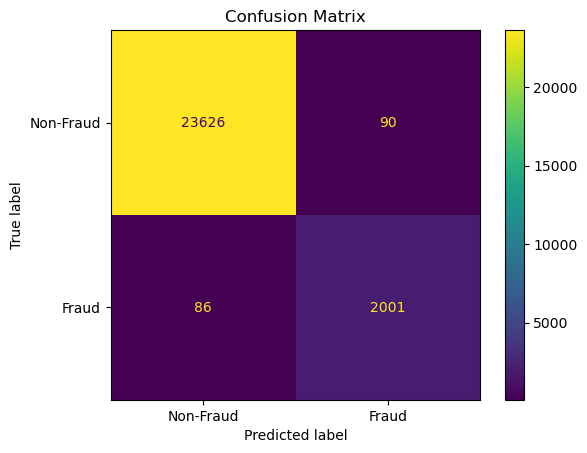

----Summary---
Accuracy: 0.9932
Precision: 0.9570
Recall: 0.9588
F1 Score: 0.9579


In [39]:
predictions, _ = compute_score_for_batch(eidx, X[unique_vertices], y[unique_vertices], batch_size=batch_size)

### Compute Shapley values of different features for a transaction
NOTE: Shapely computation is very expensive

In [40]:
NR_TX =  test_ei.shape[0]//4
batch_size = 1 

transaction_batch = np.random.choice(NR_TX, size=batch_size, replace=False)
idx_of_edges = transaction_batch.reshape(-1, 1) + np.arange(4)*NR_TX

edges_batch = test_ei.iloc[idx_of_edges.ravel()]
unique_vertices, renumbered_edges =  np.unique(edges_batch.values, return_inverse=True)


predictions, shap_values = compute_score_for_batch(renumbered_edges.reshape(edges_batch.shape), X[unique_vertices], y[unique_vertices], batch_size=batch_size, shap=True, feature_mask=feature_mask)

In [41]:
feature_to_attribution_map = dict(zip(feature_mask, shap_values[2]))
feature_name_to_id_map = {v:k for k, v in mask_mapping.items()}

#### Shapley values for different features

In [42]:
{feature_name_to_id_map[k]: f"{v:.3f}" for k, v in feature_to_attribution_map.items()}

{'Card': '-0.000',
 'Merchant': '-0.000',
 'MCC': '-0.000',
 'City': '0.000',
 'Errors': '0.000',
 'Zip': '0.001',
 'Chip': '-0.001',
 'Amount': '0.000'}